# MaxDiff (Best-Worst Scaling)

MaxDiff is a survey methodology for ranking a large pool of items by preference. Respondents see
rotating subsets of the items and, for each subset, pick the **best** and **worst**. The method
has become a workhorse in conjoint / pricing / product research because it:

- Avoids the well-known biases of rating scales (scale use heterogeneity, acquiescence).
- Forces discrimination — respondents cannot rate everything "important".
- Recovers item utilities on a common scale that supports *share-of-preference* calculations.

This notebook walks through hierarchical Bayesian MaxDiff with
[`MaxDiffMixedLogit`](../../api/generated/pymc_marketing.customer_choice.MaxDiffMixedLogit.rst):
synthetic data → model fit → recovery diagnostics → respondent heterogeneity →
share-of-preference output.


In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

from pymc_marketing.customer_choice import (
    MaxDiffMixedLogit,
    generate_maxdiff_data,
)

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
%config InlineBackend.figure_format = "retina"

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100

SEED = 42
rng = np.random.default_rng(SEED)

## Model

For each task $t$ a respondent $r$ sees a subset $S_t$ of the item pool and picks a best item $b_t$
and worst item $w_t$. The Louviere *sequential best-worst* likelihood decomposes the joint pick as

$$
P(b_t, w_t \mid S_t) = \underbrace{\mathrm{softmax}_{j \in S_t}(U_{rj})_{b_t}}_{\text{best pick}} \times
\underbrace{\mathrm{softmax}_{j \in S_t \setminus \{b_t\}}(-U_{rj})_{w_t}}_{\text{worst pick (sign-flipped)}}.
$$

Item utilities $U_{rj}$ decompose into a population-level item intercept plus a per-respondent deviation:

$$
U_{rj} = \beta_j + \sigma_j z_{rj}, \qquad z_{rj} \sim \mathcal{N}(0, 1),
$$

with the reference item pinned to $\beta_{\text{ref}} = 0$ for identification. Only utility
*contrasts* against the reference item are identified — absolute utility levels are arbitrary.


## Synthetic data

`generate_maxdiff_data` draws subsets uniformly at random (a real field design would use a
balanced incomplete block design) and simulates best / worst picks under the Louviere model.
It returns a long-format `DataFrame` and a dictionary of the true utilities we want to recover.


In [3]:
task_df, ground_truth = generate_maxdiff_data(
    n_respondents=200,
    n_items=10,
    n_tasks_per_resp=12,
    subset_size=4,
    sigma_respondent=0.4,
    random_seed=SEED,
)

items = ground_truth["items"]
true_utilities = ground_truth["utilities"]
task_df.head()

,respondent_id,task_id,item_id,is_best,is_worst
0,r0,0,item_1,1,0
1,r0,0,item_0,0,0
2,r0,0,item_9,0,0
3,r0,0,item_3,0,1
4,r0,1,item_7,0,0


Each row is one *shown item in one task*. Exactly one row per `(respondent_id, task_id)` group
carries `is_best=1` and one carries `is_worst=1`.


In [4]:
grouped = task_df.groupby(["respondent_id", "task_id"])
print(f"respondents: {task_df['respondent_id'].nunique()}")
print(f"tasks:       {grouped.ngroups}")
print(f"rows:        {len(task_df)}  (= tasks x subset_size)")
print(f"items:       {len(items)}")

respondents: 200
tasks:       2400
rows:        9600  (= tasks x subset_size)
items:       10


## Data format and `prepare_maxdiff_data`

The long-format `task_df` above is the natural export from Sawtooth / Qualtrics / Conjointly.
Internally, `MaxDiffMixedLogit` reshapes it into a padded-plus-mask representation via
[`prepare_maxdiff_data`](../../api/generated/pymc_marketing.customer_choice.prepare_maxdiff_data.rst).
You can call the helper directly to inspect what the model consumes — useful when debugging
imports from survey platforms.

In [5]:
from pymc_marketing.customer_choice import prepare_maxdiff_data

arrays = prepare_maxdiff_data(task_df, items=items)

print(f"n_tasks      = {arrays['n_tasks']}")
print(f"n_respondents= {arrays['n_respondents']}")
print(f"n_items      = {arrays['n_items']}")
print(f"k_max        = {arrays['k_max']} (largest subset size)\n")

print("item_idx[:5]   (items shown per task, as ints into `items`):")
print(arrays["item_idx"][:5])
print("\nmask[:5]       (True = real shown item, False = padding):")
print(arrays["mask"][:5])
print("\nbest_pos[:5]   (position 0..k_max-1 of the best pick):")
print(arrays["best_pos"][:5])
print("\nworst_pos[:5]  (position of the worst pick):")
print(arrays["worst_pos"][:5])
print("\nresp_idx[:5]   (respondent index per task):")
print(arrays["resp_idx"][:5])

n_tasks      = 2400
n_respondents= 200
n_items      = 10
k_max        = 4 (largest subset size)

item_idx[:5]   (items shown per task, as ints into `items`):
[[1 0 9 3]
 [7 9 0 2]
 [8 4 5 9]
 [1 3 2 4]
 [7 6 3 1]]

mask[:5]       (True = real shown item, False = padding):
[[ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]]

best_pos[:5]   (position 0..k_max-1 of the best pick):
[0 2 3 1 1]

worst_pos[:5]  (position of the worst pick):
[3 3 1 3 3]

resp_idx[:5]   (respondent index per task):
[0 0 0 0 0]


### Ragged subsets and input validation

Real MaxDiff designs occasionally mix subset sizes within a single study. When a `task_df` has
ragged subsets, `prepare_maxdiff_data` pads the shorter tasks with the reference item; the
`mask` array records which positions are real so the model ignores padding in the softmax.

The helper also validates the data up front and raises a descriptive `ValueError` on malformed
inputs — missing best/worst picks, duplicate best picks, best == worst in the same task,
duplicate items within a task, or items outside the declared pool:

In [6]:
bad_df = task_df.copy()
# Corrupt the first task: remove the best pick
first_task = (bad_df["respondent_id"] == "r0") & (bad_df["task_id"] == 0)
bad_df.loc[first_task, "is_best"] = 0

try:
    prepare_maxdiff_data(bad_df, items=items)
except ValueError as e:
    print(f"Caught expected error:\n  {e}")

Caught expected error:
  Task ('r0', np.int64(0)) has 0 best picks; exactly one is required.


## Fit


In [15]:
model = MaxDiffMixedLogit(task_df=task_df, items=items)
idata = model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.9,
    random_seed=SEED,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

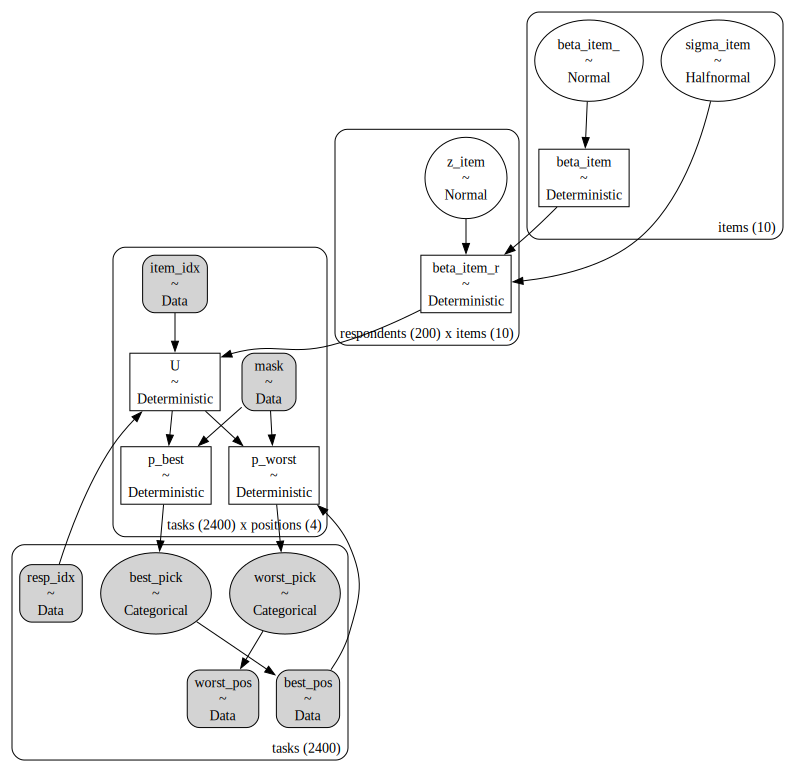

In [16]:
pm.model_to_graphviz(model.model)

## Parameter recovery

Plot posterior item utilities against the ground truth. The dashed 45° line is perfect recovery.


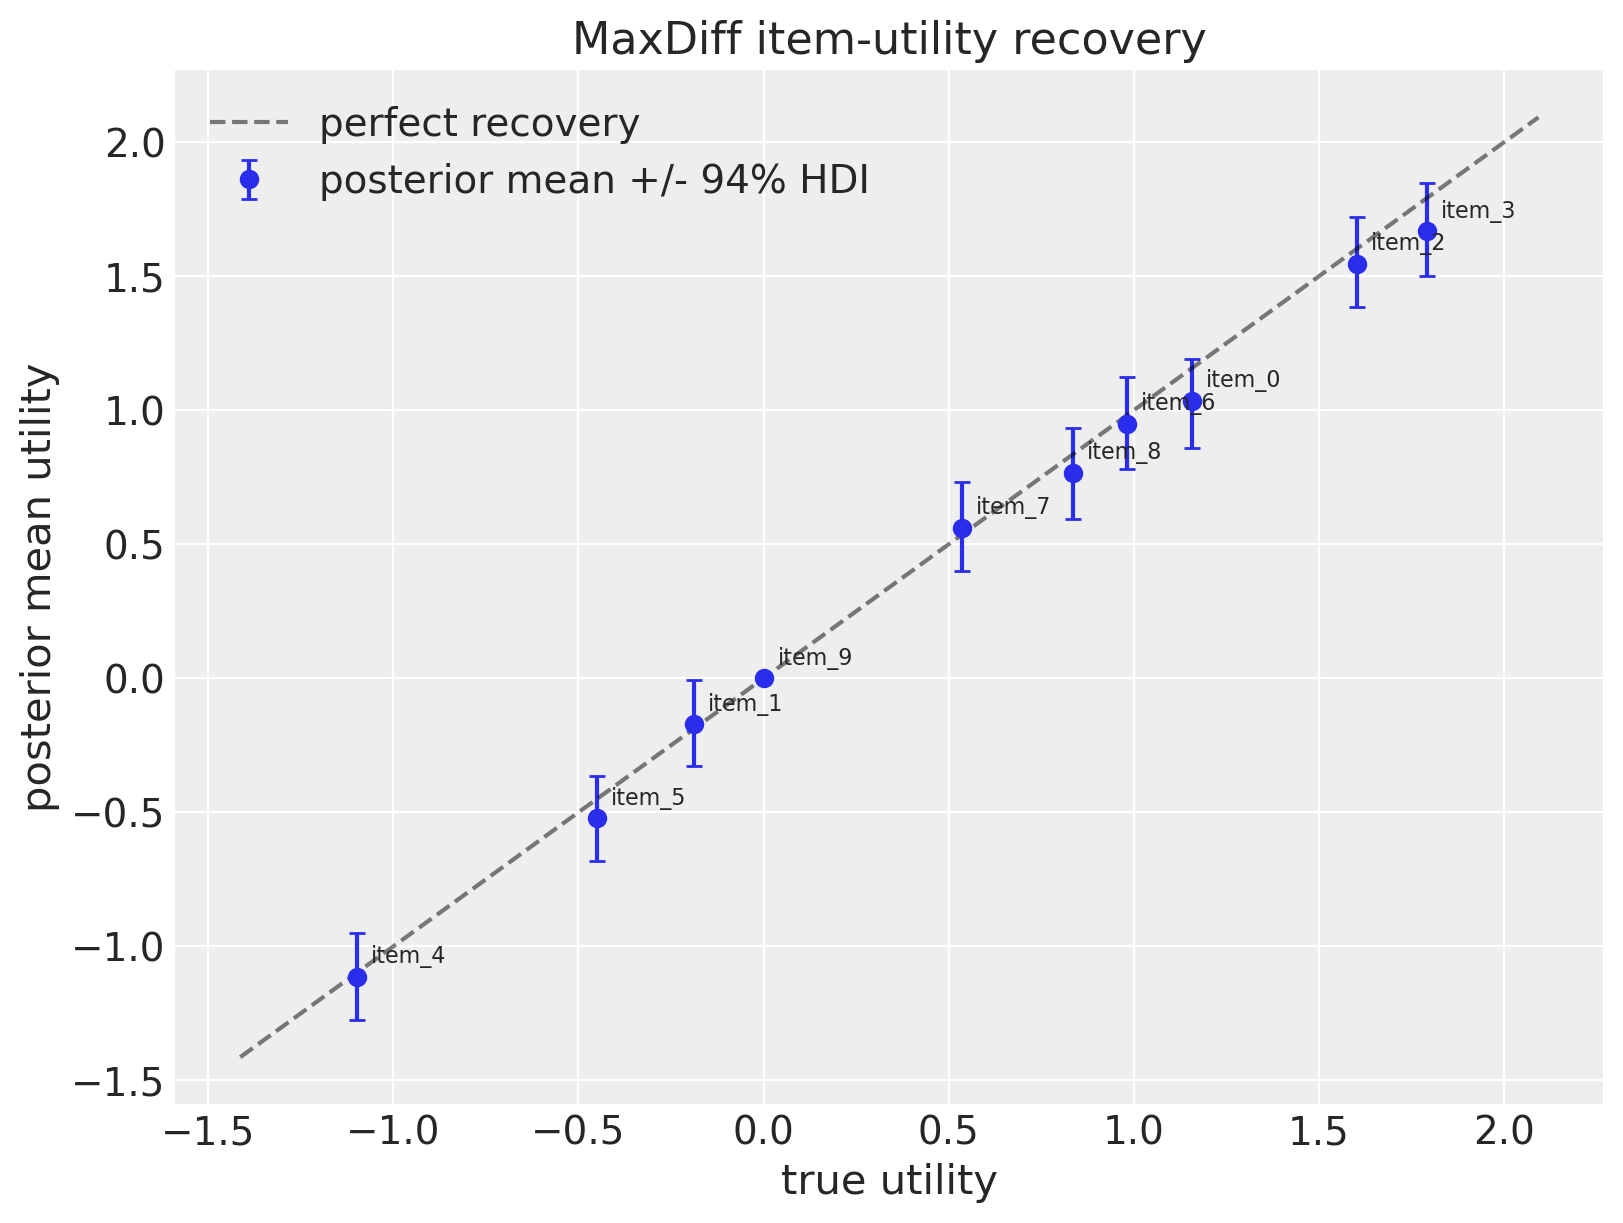

In [17]:
posterior = idata["posterior"]["beta_item"]
post_mean = posterior.mean(dim=("chain", "draw")).values
post_hdi = az.hdi(posterior, hdi_prob=0.94)["beta_item"].values  # (items, 2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(
    true_utilities,
    post_mean,
    yerr=np.abs(post_hdi.T - post_mean),
    fmt="o",
    capsize=3,
    label="posterior mean +/- 94% HDI",
)
lo = min(true_utilities.min(), post_mean.min()) - 0.3
hi = max(true_utilities.max(), post_mean.max()) + 0.3
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5, label="perfect recovery")
for i, name in enumerate(items):
    ax.annotate(
        name,
        (true_utilities[i], post_mean[i]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.set_xlabel("true utility")
ax.set_ylabel("posterior mean utility")
ax.set_title("MaxDiff item-utility recovery")
ax.legend()
plt.show()

In [10]:
az.summary(idata, var_names=["beta_item", "sigma_item"], round_to=2)

/Users/nathanielforde/mambaforge/envs/pymc-marketing-dev/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/nathanielforde/mambaforge/envs/pymc-marketing-dev/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_item[item_0],1.04,0.09,0.88,1.21,0.00,0.00,852.62,1105.65,1.00
beta_item[item_1],-0.17,0.09,-0.32,0.00,0.00,0.00,853.08,1124.57,1.00
beta_item[item_2],1.55,0.09,1.38,1.71,0.00,0.00,750.68,1137.03,1.00
beta_item[item_3],1.67,0.09,1.51,1.85,0.00,0.00,800.35,1149.20,1.00
beta_item[item_4],-1.11,0.09,-1.27,-0.95,0.00,0.00,945.02,1612.82,1.00
beta_item[item_5],-0.52,0.08,-0.68,-0.36,0.00,0.00,806.49,1012.09,1.00
beta_item[item_6],0.95,0.09,0.77,1.12,0.00,0.00,792.95,1201.80,1.00
beta_item[item_7],0.56,0.09,0.40,0.74,0.00,0.00,758.57,1150.30,1.00
beta_item[item_8],0.77,0.09,0.59,0.94,0.00,0.00,741.48,1189.85,1.00
beta_item[item_9],0.00,0.00,0.00,0.00,0.00,NaN,2000.00,2000.00,NaN


## Respondent heterogeneity

`beta_item_r` holds per-respondent item utilities. A forest of the first few respondents shows
how strongly preferences vary — the motivation for the hierarchical layer.


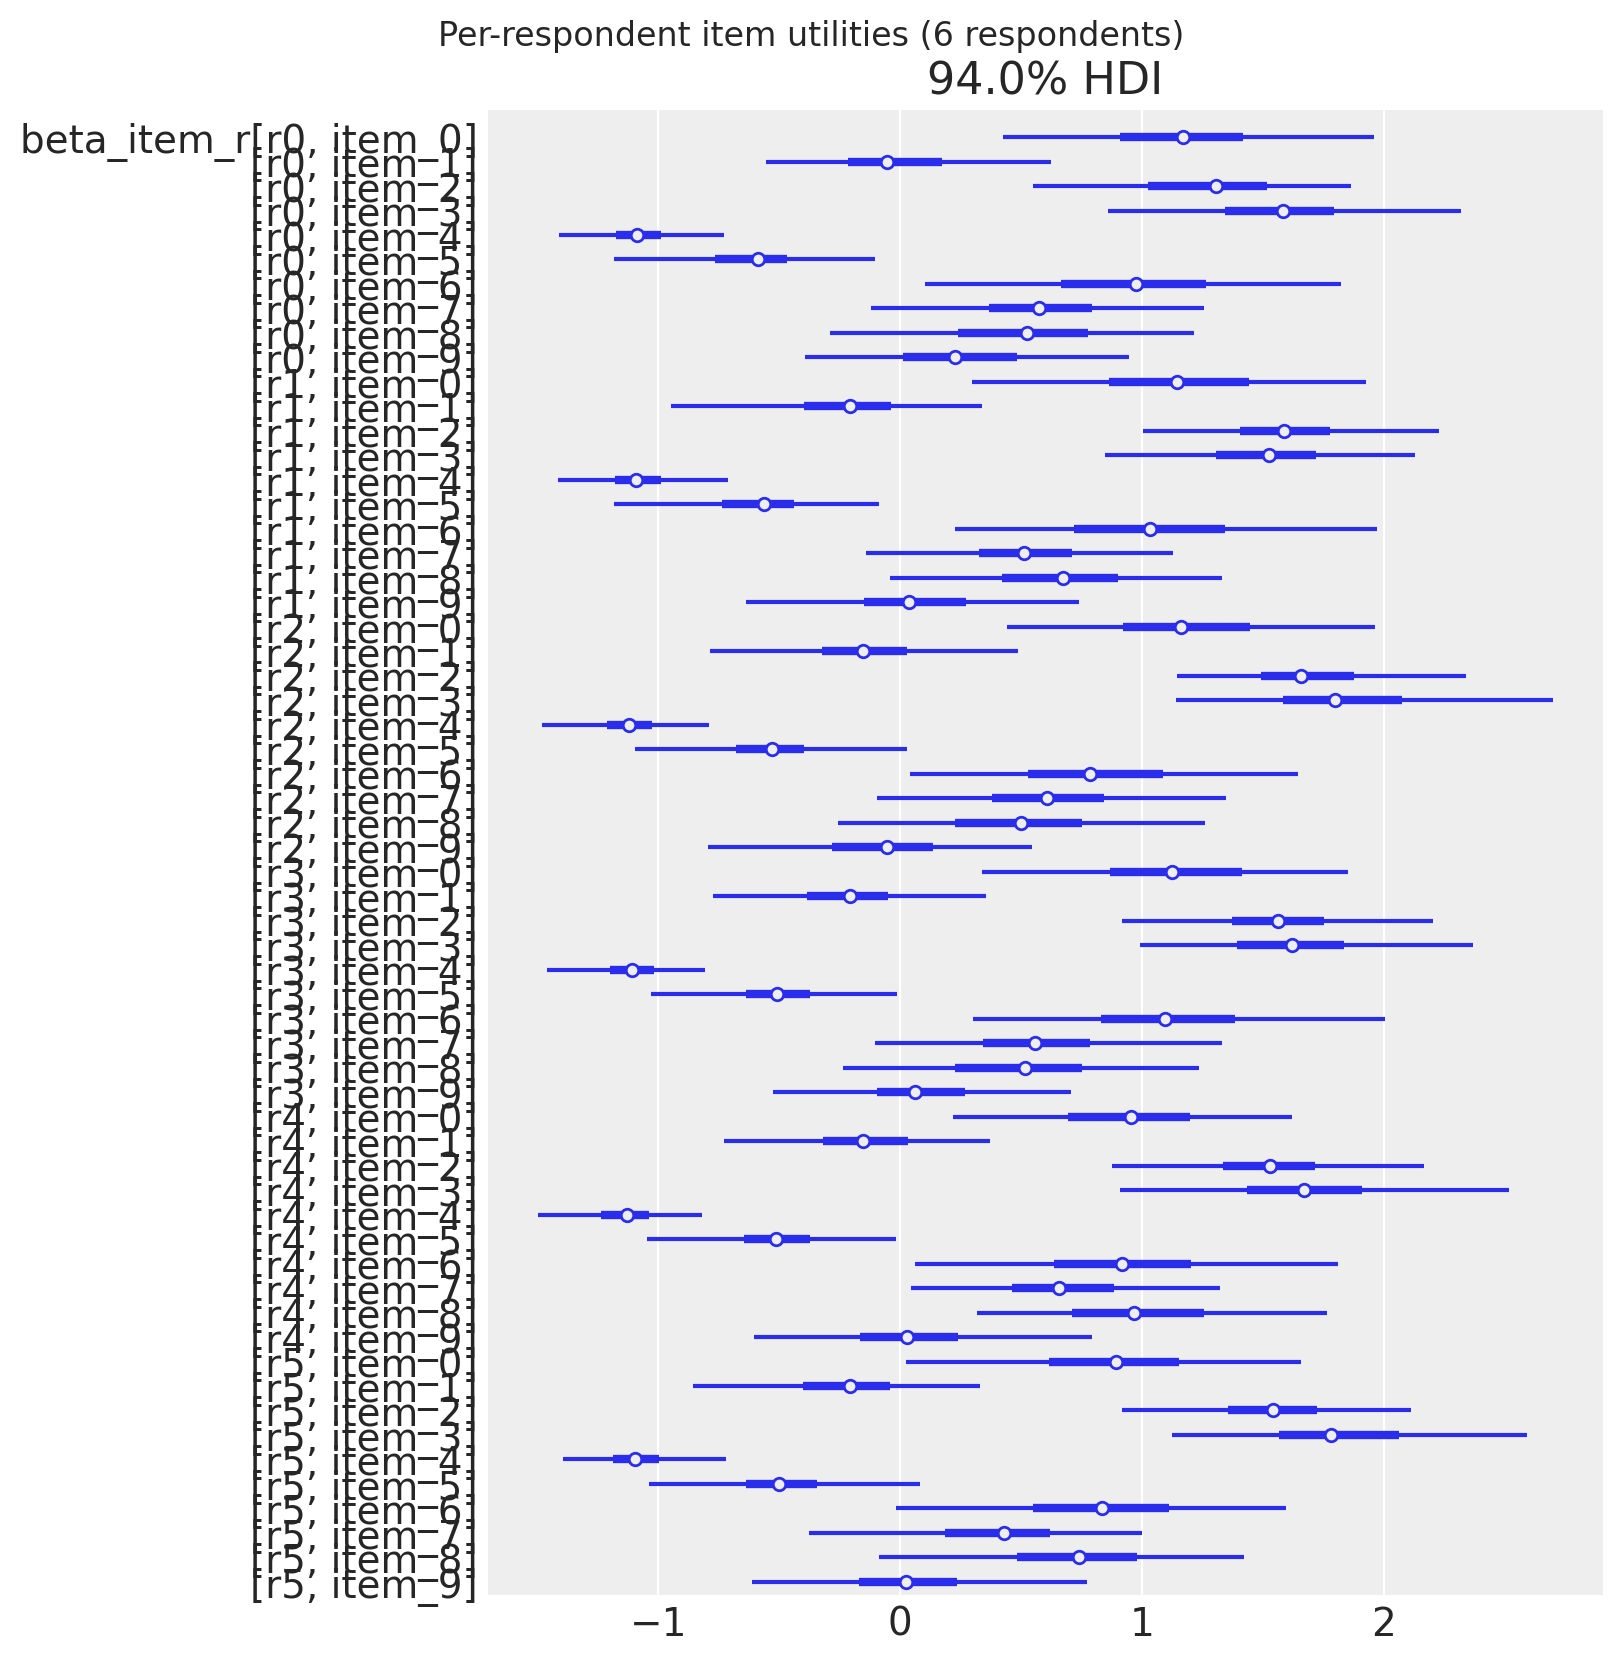

In [11]:
resp_sample = idata["posterior"]["beta_item_r"].isel(respondents=slice(0, 6))
az.plot_forest(
    resp_sample,
    combined=True,
    figsize=(8, 8),
)
plt.suptitle("Per-respondent item utilities (6 respondents)", y=1.02)
plt.show()

## Share of preference

The common consulting deliverable: given the posterior utilities, what fraction of respondents
would pick each item if all items were shown together? This is just the softmax of the posterior
item utilities averaged over draws.


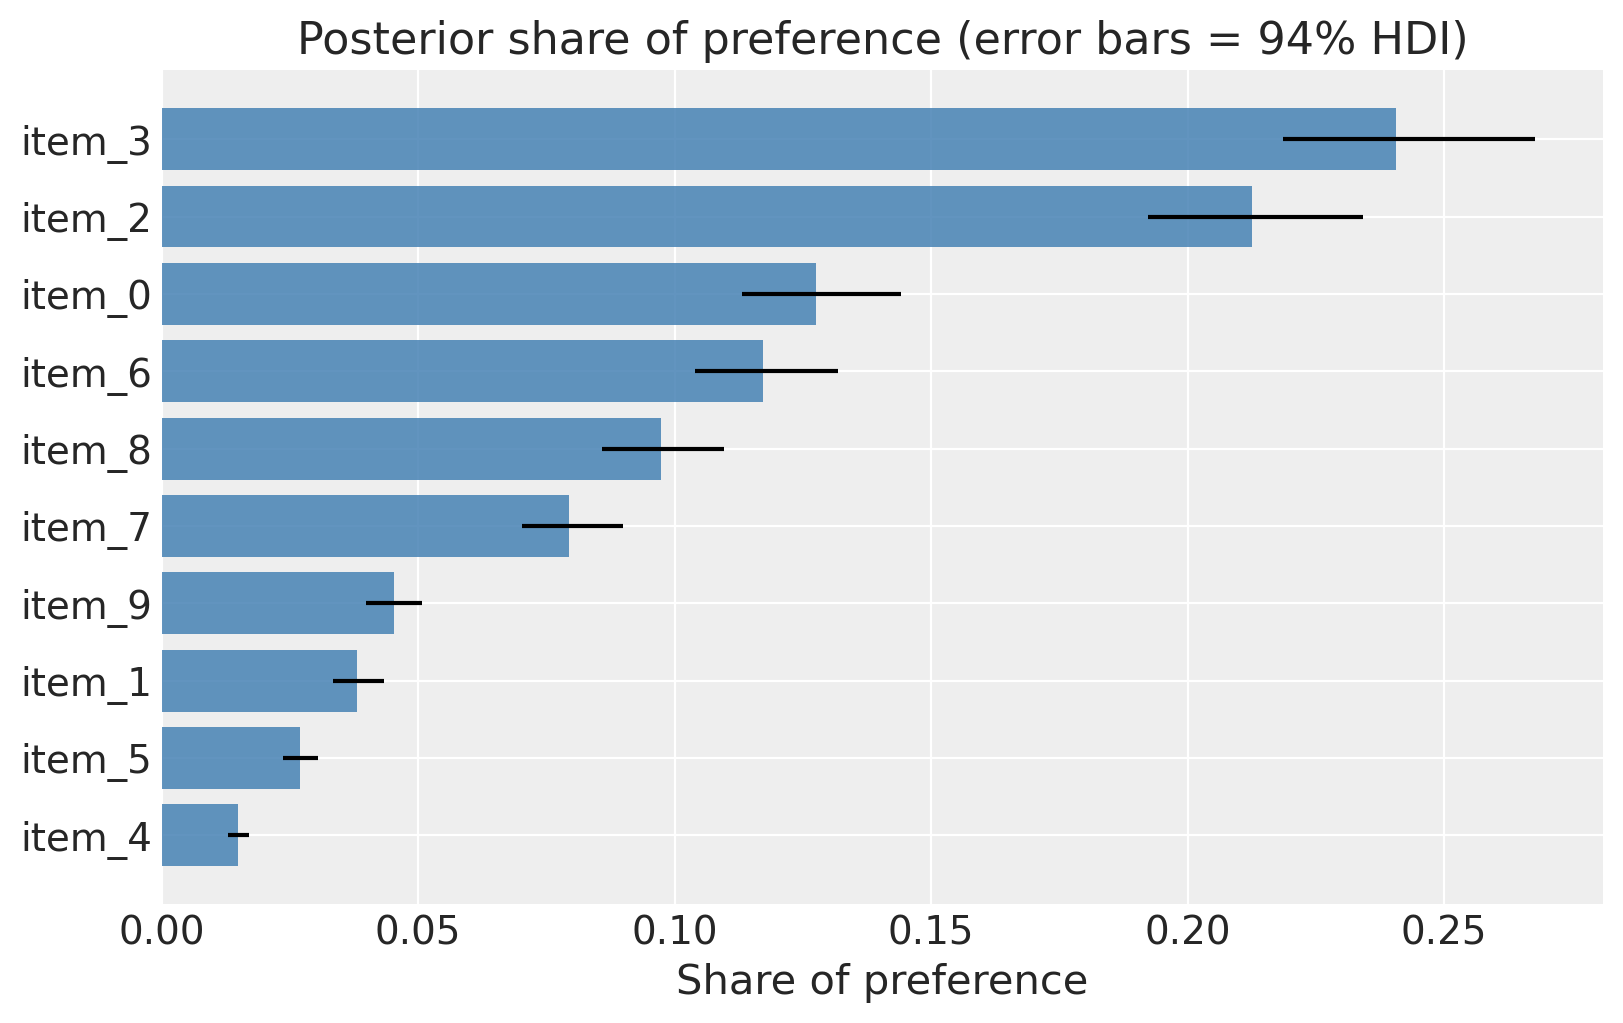

In [12]:
beta_draws = (
    idata["posterior"]["beta_item"].stack(sample=("chain", "draw")).values
)  # (items, samples)
# Softmax across items for each draw
beta_shift = beta_draws - beta_draws.max(axis=0, keepdims=True)
exp_b = np.exp(beta_shift)
shares = exp_b / exp_b.sum(axis=0, keepdims=True)  # (items, samples)

share_mean = shares.mean(axis=1)
share_hdi = np.quantile(shares, [0.03, 0.97], axis=1)

order = np.argsort(share_mean)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(items))
ax.barh(
    y_pos,
    share_mean[order],
    xerr=np.abs(share_hdi[:, order] - share_mean[order]),
    color="steelblue",
    alpha=0.85,
)
ax.set_yticks(y_pos)
ax.set_yticklabels([items[i] for i in order])
ax.invert_yaxis()
ax.set_xlabel("Share of preference")
ax.set_title("Posterior share of preference (error bars = 94% HDI)")
plt.show()

## Counterfactual: restricted-assortment share of preference

A real business question: *if we discontinued items 7, 8 and 9, how would demand shift to the
survivors?* This is a genuinely out-of-sample prediction — the restricted assortment was never
shown during the survey.

`predict_choices` answers it by building a synthetic task where every respondent is shown the
counterfactual item set, then generatively sampling per-respondent best (and worst) picks from
the posterior. Because `beta_item_r` captures per-respondent preferences, the resulting
substitution pattern is **preference-weighted** — respondents who liked a dropped item don't
all move to the same survivor.

The comparison below contrasts this against the naive baseline that simply renormalises the
full-pool shares over the restricted set — the sort of answer you'd get without a choice model.

In [ ]:
import pandas as pd

# Counterfactual assortment: items 3, 8, 9 are discontinued.
dropped = {"item_3", "item_2", "item_9"}
restricted_items = [it for it in items if it not in dropped]
print(f"Restricted assortment ({len(restricted_items)} items): {restricted_items}")

# Build a counterfactual task_df: every respondent sees the restricted set in one task.
# The is_best / is_worst flags are dummies -- predict_choices regenerates both.
cf_rows = []
for r in task_df["respondent_id"].unique():
    for pos, it in enumerate(restricted_items):
        cf_rows.append(
            {
                "respondent_id": r,
                "task_id": 0,
                "item_id": it,
                "is_best": int(pos == 0),
                "is_worst": int(pos == len(restricted_items) - 1),
            }
        )
cf_df = pd.DataFrame(cf_rows)

cf_preds = model.predict_choices(cf_df, random_seed=SEED)

# best_pick shape: (chain, draw, tasks). Here tasks == n_respondents, and every task uses
# the same position -> item mapping, so we can convert positions directly.
best_positions = cf_preds["best_pick"].values
restricted_arr = np.array(restricted_items)
best_item_per_draw = restricted_arr[best_positions]  # (chain, draw, respondents)

# Model-based share: fraction of (chain, draw, respondent) picks landing on each item,
# with per-draw shares retained for uncertainty bands.
cf_share_per_draw = np.stack(
    [(best_item_per_draw == it).mean(axis=-1) for it in restricted_items]
)  # (items, chain, draw)
cf_share_mean = cf_share_per_draw.mean(axis=(1, 2))
cf_share_hdi = np.quantile(
    cf_share_per_draw.reshape(len(restricted_items), -1), [0.03, 0.97], axis=1
)
print("------ Counterfactual Share ------")
print(cf_share_mean)

# Naive baseline: renormalise full-pool shares over the restricted set.
full_share_map = dict(zip(items, share_mean, strict=True))
naive_share = np.array([full_share_map[it] for it in restricted_items])
naive_share = naive_share / naive_share.sum()
print("------- Naive Share -------")
print(naive_share)

Restricted assortment (7 items): ['item_0', 'item_1', 'item_4', 'item_5', 'item_6', 'item_7', 'item_8']
------ Counterfactual Share ------
[0.253325   0.0754625  0.0289025  0.0530175  0.23558625 0.1581625
 0.19554375]
------- Naive Share -------
[0.25445055 0.07611029 0.02969411 0.05360531 0.23374135 0.15823224
 0.19416615]


/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_8978/2766163016.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


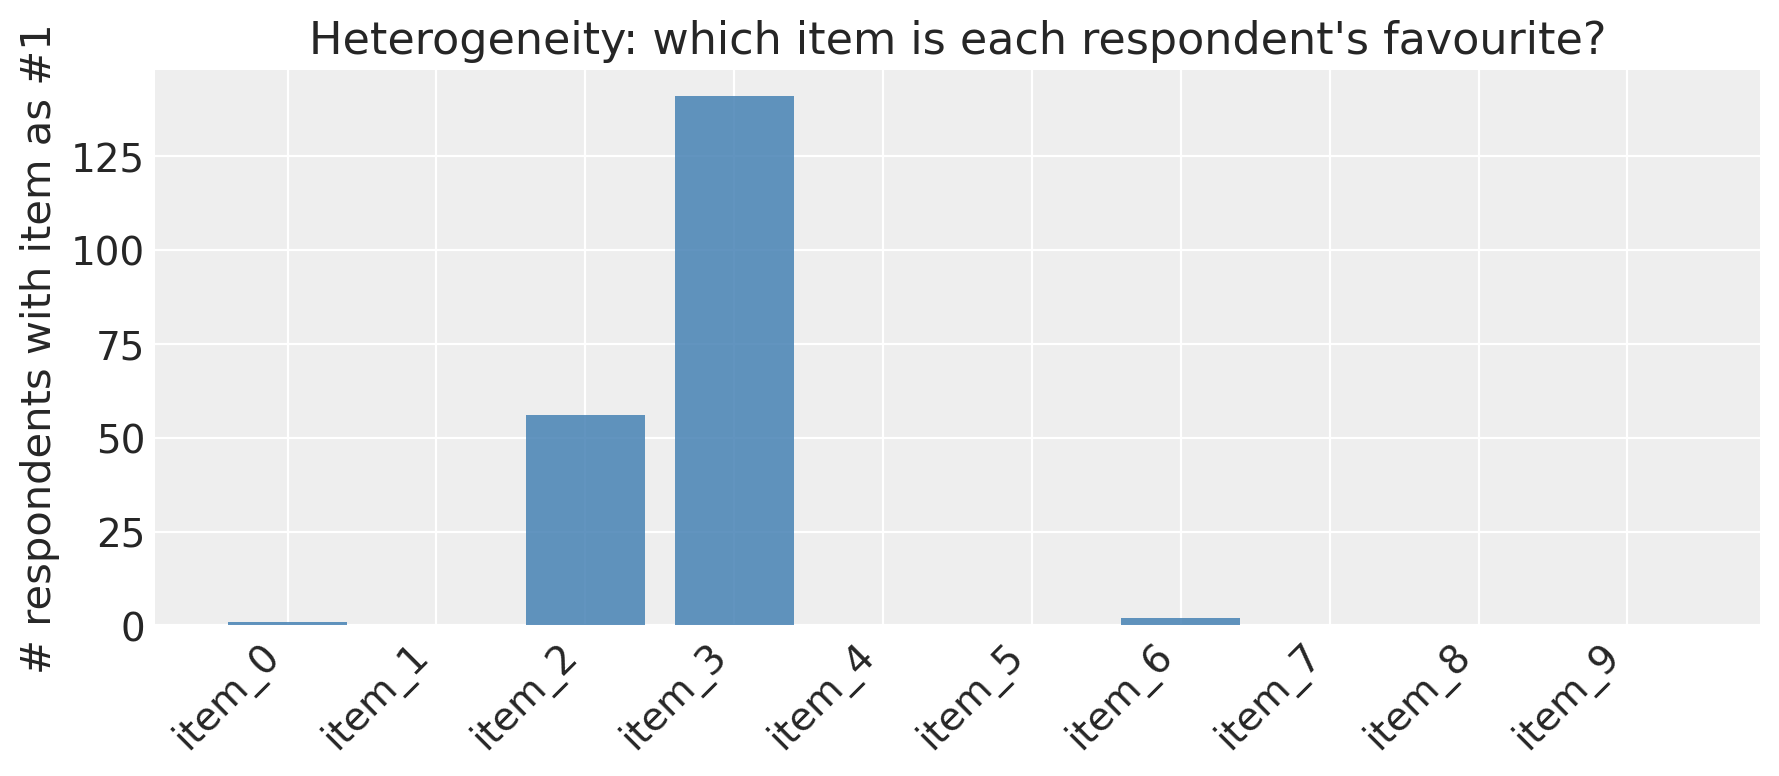

In [19]:
beta_r_mean = (
    idata["posterior"]["beta_item_r"].mean(dim=("chain", "draw")).values
)  # (R, I)
top_item_idx = np.argmax(beta_r_mean, axis=1)
top_item_counts = (
    pd.Series([items[i] for i in top_item_idx], name="top_item")
    .value_counts()
    .reindex(items, fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(items)), top_item_counts.values, color="steelblue", alpha=0.85)
ax.set_xticks(range(len(items)))
ax.set_xticklabels(top_item_counts.index, rotation=45, ha="right")
ax.set_ylabel("# respondents with item as #1")
ax.set_title("Heterogeneity: which item is each respondent's favourite?")
plt.tight_layout()
plt.show()

## Caveats and follow-ups

- **Design**: real MaxDiff studies use balanced incomplete block designs (Sawtooth/Lighthouse).
  This model does not care which design produced the data — but efficiency is much higher
  under balanced rotations.
- **Item-attribute part-worths**: when items share structure (price, brand, feature levels),
  a linear utility over item covariates $U_j = x_j^\top \beta$ gains efficiency.
  — file an issue if you need it.
- **Anchored MaxDiff**: a dual-response variant that also calibrates utilities to an
  "important vs. not" threshold.
- **Identification**: the reference item's utility is fixed at 0. Absolute levels are not
  identifiable; compare items via contrasts or via share-of-preference.
